In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

Matplotlib is building the font cache; this may take a moment.


In [2]:
train_dir = "../data/train"
test_dir = "../data/test"

In [3]:
os.listdir(train_dir)

['happy', 'sad', 'fear', 'surprise', 'neutral', 'angry', 'disgust']

In [4]:
class_counts = {}

for emotion in os.listdir(train_dir):
    
    emotion_path = os.path.join(train_dir, emotion)

    if os.path.isdir(emotion_path):
        class_counts[emotion] = len(os.listdir(emotion_path))

class_counts

{'happy': 7215,
 'sad': 4830,
 'fear': 4097,
 'surprise': 3171,
 'neutral': 4965,
 'angry': 3995,
 'disgust': 436}

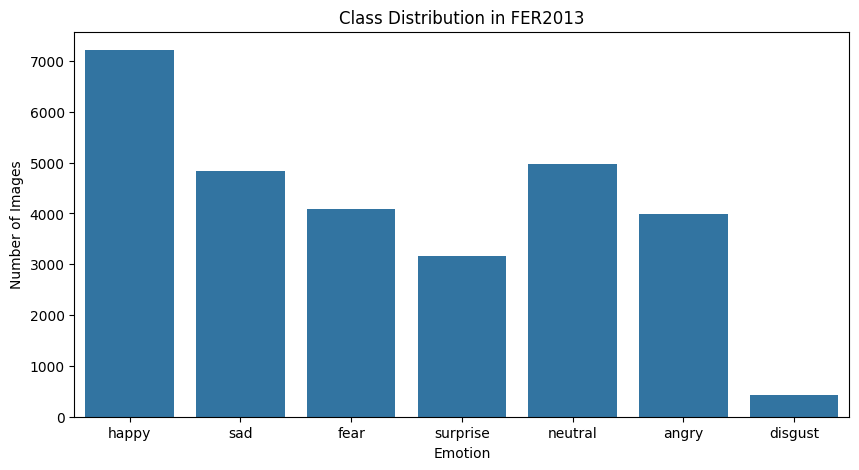

In [5]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=list(class_counts.keys()),
    y=list(class_counts.values())
)

plt.title("Class Distribution in FER2013")
plt.xlabel("Emotion")
plt.ylabel("Number of Images")

plt.show()

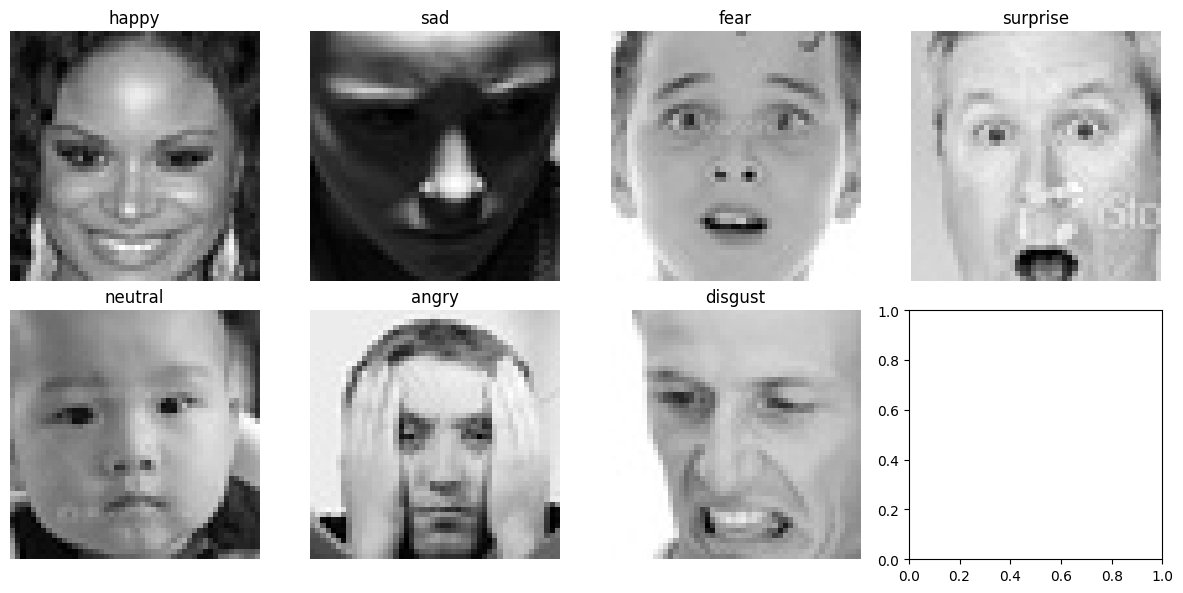

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

axes = axes.flatten()

for idx, emotion in enumerate(os.listdir(train_dir)[:7]):

    emotion_path = os.path.join(train_dir, emotion)

    image_name = random.choice(os.listdir(emotion_path))

    image_path = os.path.join(emotion_path, image_name)

    image = Image.open(image_path)

    axes[idx].imshow(image, cmap="gray")
    axes[idx].set_title(emotion)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [7]:
sample_emotion = random.choice(os.listdir(train_dir))

sample_path = os.path.join(
    train_dir,
    sample_emotion,
    random.choice(os.listdir(os.path.join(train_dir, sample_emotion)))
)

image = Image.open(sample_path)

image_array = np.array(image)

print("Image shape:", image_array.shape)

Image shape: (48, 48)


In [8]:
print("Minimum pixel value:", image_array.min())
print("Maximum pixel value:", image_array.max())

Minimum pixel value: 22
Maximum pixel value: 199


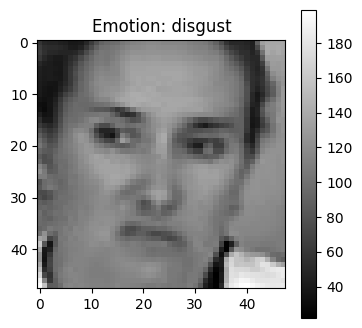

In [9]:
plt.figure(figsize=(4,4))

plt.imshow(image_array, cmap="gray")

plt.title(f"Emotion: {sample_emotion}")

plt.colorbar()

plt.show()

# EDA Observations

## Dataset Findings

- FER2013 contains grayscale facial images of size 48×48.
- The dataset is imbalanced, especially for the disgust class.
- Several images are blurry, noisy, and low contrast.
- Some emotions visually overlap, especially fear and surprise.
- Small image resolution makes emotion recognition difficult.
- Data augmentation and regularization will likely be important.

# Phase 2 — Data Pipeline

In [12]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor()
])


In [15]:
from PIL import Image
image_path = "../data/train/happy/Training_1866804.jpg"

image = Image.open(image_path)

image

tensor_image = transform(image)

tensor_image.shape

torch.Size([1, 48, 48])

We imported one image manually

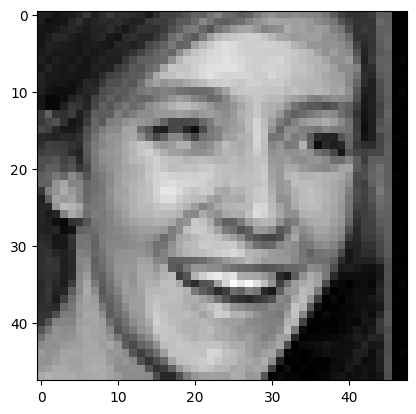

In [17]:
import matplotlib.pyplot as plt
plt.imshow(
    tensor_image.squeeze(),
    cmap="gray"
)

plt.show()

In [18]:
transform = transforms.Compose([
    
    transforms.Resize((48, 48)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(10),
    
    transforms.ToTensor()
])

Rotation and Horizantal Flip transformation

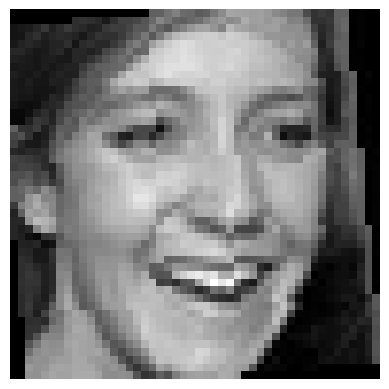

In [27]:
tensor_image = transform(image)

plt.imshow(
    tensor_image.squeeze(),
    cmap="gray"
)

plt.axis("off")

plt.show()

In [39]:
transform = transforms.Compose([
    
    transforms.Resize((48, 48)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(10),
    
    transforms.ColorJitter(
        brightness=0.2
    ),
    
    transforms.ToTensor()
])

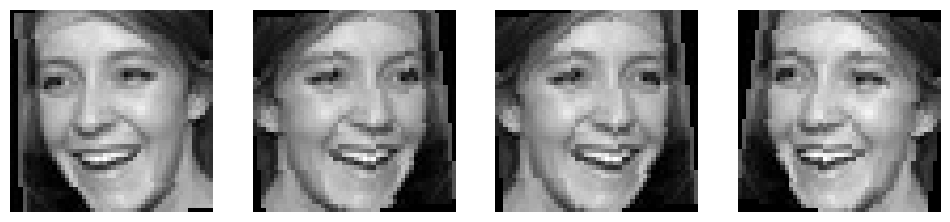

In [40]:
fig, axes = plt.subplots(1, 4, figsize=(12,4))

for i in range(4):
    
    aug_img = transform(image)
    
    axes[i].imshow(
        aug_img.squeeze(),
        cmap="gray"
    )
    
    axes[i].axis("off")

plt.show()

In [41]:
from torchvision import datasets
train_dataset = datasets.ImageFolder(
    root="../data/train",
    transform=transform
)

In [42]:
train_dataset
train_dataset.class_to_idx

{'angry': 0,
 'disgust': 1,
 'fear': 2,
 'happy': 3,
 'neutral': 4,
 'sad': 5,
 'surprise': 6}

In [43]:
image, label = train_dataset[0]

In [44]:
print(image.shape)
print(label)

torch.Size([3, 48, 48])
0


In [45]:
from torch.utils.data import DataLoader

In [49]:
BATCH_SIZE = 64

In [50]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [51]:
images, labels = next(iter(train_loader))

In [52]:
print(images.shape)
print(labels.shape)

torch.Size([64, 3, 48, 48])
torch.Size([64])


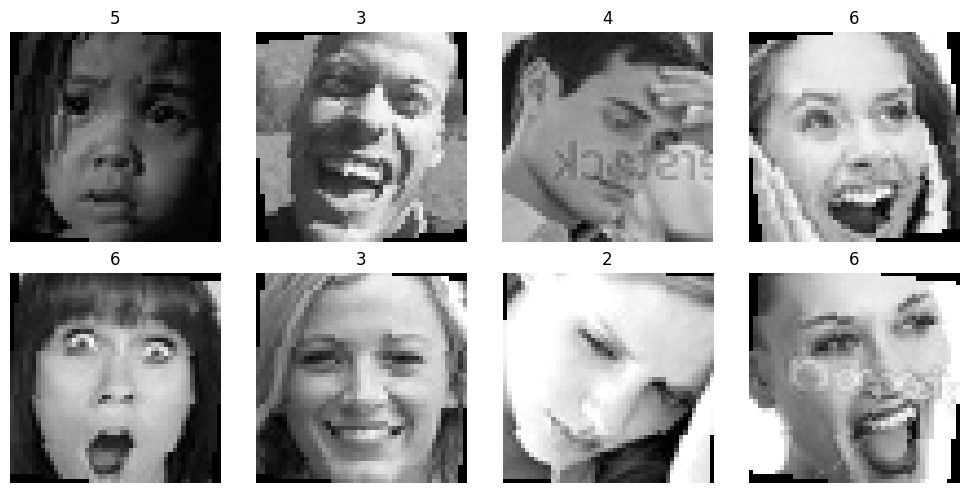

In [55]:
fig, axes = plt.subplots(2, 4, figsize=(10,5))

axes = axes.flatten()

for i in range(8):

    axes[i].imshow(
        images[i].permute(1,2,0)
    )

    axes[i].set_title(labels[i].item())

    axes[i].axis("off")

plt.tight_layout()

plt.show()

In [56]:
idx_to_class = {
    v:k for k,v in train_dataset.class_to_idx.items()
}

In [58]:
transform = transforms.Compose([
    
    transforms.Grayscale(num_output_channels=1),
    
    transforms.Resize((48, 48)),
    
    transforms.RandomHorizontalFlip(),
    
    transforms.RandomRotation(10),
    
    transforms.ColorJitter(
        brightness=0.2
    ),
    
    transforms.ToTensor()
])

In [59]:
train_dataset = datasets.ImageFolder(
    root="../data/train",
    transform=transform
)

In [60]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [61]:
images, labels = next(iter(train_loader))

In [62]:
print(images.shape)

torch.Size([64, 1, 48, 48])


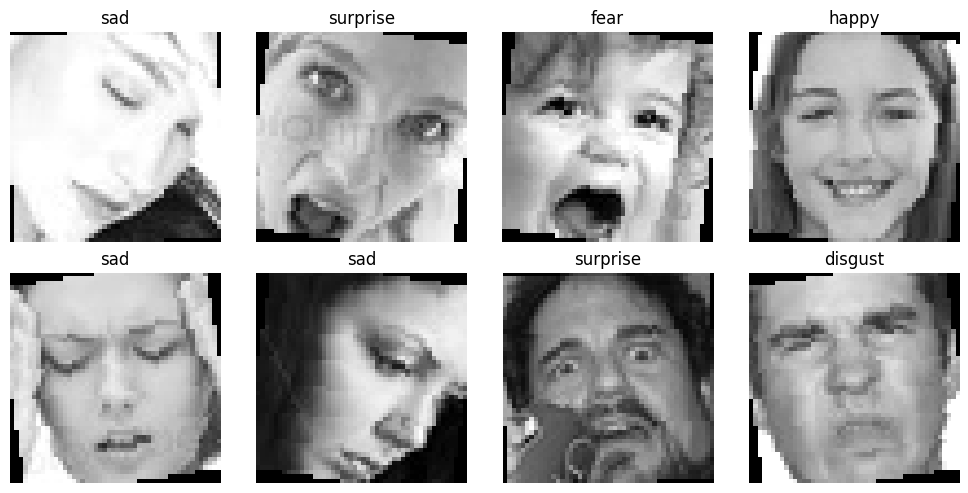

In [63]:
fig, axes = plt.subplots(2, 4, figsize=(10,5))

axes = axes.flatten()

for i in range(8):

    axes[i].imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    label_name = idx_to_class[
        labels[i].item()
    ]

    axes[i].set_title(label_name)

    axes[i].axis("off")

plt.tight_layout()

plt.show()

In [64]:
from torch.utils.data import WeightedRandomSampler

In [65]:
targets = train_dataset.targets

print(targets[:10])

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [66]:
class_counts = np.bincount(targets)

print(class_counts)

[3995  436 4097 7215 4965 4830 3171]


In [67]:
class_weights = 1. / class_counts

print(class_weights)

[0.00025031 0.00229358 0.00024408 0.0001386  0.00020141 0.00020704
 0.00031536]


In [68]:
sample_weights = [
    class_weights[label]
    for label in targets
]

In [69]:
sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [70]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

In [71]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 1, 48, 48])
torch.Size([64])


In [72]:
transform = transforms.Compose([
    
    transforms.Grayscale(num_output_channels=1),

    transforms.Resize((48, 48)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5],
        std=[0.5]
    )
])

In [73]:
train_dataset = datasets.ImageFolder(
    root="../data/train",
    transform=transform
)

In [74]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler
)

In [75]:
images, labels = next(iter(train_loader))

In [76]:
print(images.min())
print(images.max())

tensor(-1.)
tensor(1.)


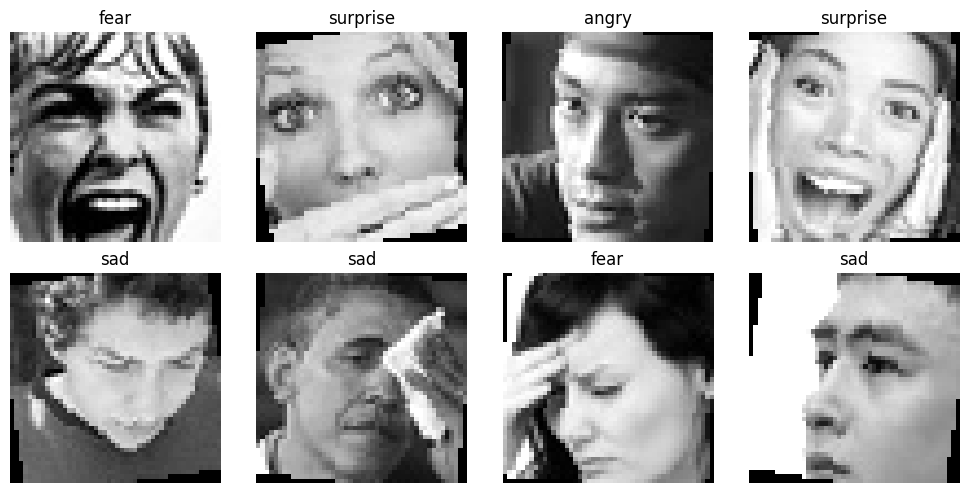

In [77]:
fig, axes = plt.subplots(2, 4, figsize=(10,5))

axes = axes.flatten()

for i in range(8):

    axes[i].imshow(
        images[i].squeeze(),
        cmap="gray"
    )

    label_name = idx_to_class[
        labels[i].item()
    ]

    axes[i].set_title(label_name)

    axes[i].axis("off")

plt.tight_layout()

plt.show()